# Roulette Dataset Exploration

Exploring the RouletteVision dataset structure and video properties.

In [3]:
# Core imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from IPython.display import Video, display
from tqdm.auto import tqdm

# Check PyTorch availability
import torch
print(f"✅ PyTorch {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# Verify dataset exists
dataset_path = Path("RouletteVision-Dataset")
assert dataset_path.exists(), "Dataset not found! Make sure it's cloned."
print(f"\n✅ Dataset found at: {dataset_path}")

✅ PyTorch 2.5.1+cu118
✅ CUDA available: True
✅ GPU: NVIDIA GeForce RTX 2070 with Max-Q Design

✅ Dataset found at: RouletteVision-Dataset


## 2. Dataset Structure

In [4]:
# Count videos in each set
sets = ["SET 1", "SET 2", "SET 3", "SET 4"]
video_counts = {}

for set_name in sets:
    input_path = dataset_path / "Input-Output Videos" / set_name
    input_videos = list(input_path.glob("*_INPUT_*.mp4"))
    output_videos = list(input_path.glob("*_OUTPUT_*.mp4"))
    video_counts[set_name] = {"input": len(input_videos), "output": len(output_videos)}
    
print("Dataset Structure:")
print("-" * 50)
for set_name, counts in video_counts.items():
    print(f"{set_name}: {counts['input']} input videos, {counts['output']} output videos")
print("-" * 50)
total_videos = sum(c['input'] for c in video_counts.values())
print(f"Total: {total_videos} video pairs")

Dataset Structure:
--------------------------------------------------
SET 1: 438 input videos, 438 output videos
SET 2: 430 input videos, 430 output videos
SET 3: 326 input videos, 326 output videos
SET 4: 509 input videos, 509 output videos
--------------------------------------------------
Total: 1703 video pairs


## 3. Video Properties

In [5]:
# Helper function to get video properties
def get_video_info(video_path):
    """Extract video metadata"""
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    cap.release()
    return {
        "fps": fps,
        "frames": frame_count,
        "resolution": (width, height),
        "duration": duration
    }

# Load sample video pair
sample_input = dataset_path / "Input-Output Videos/SET 1/S1_INPUT_1.mp4"
sample_output = dataset_path / "Input-Output Videos/SET 1/S1_OUTPUT_1.mp4"

input_info = get_video_info(sample_input)
output_info = get_video_info(sample_output)

print("📹 INPUT VIDEO (ball spinning):")
print(f"   Resolution: {input_info['resolution'][0]}x{input_info['resolution'][1]}")
print(f"   Duration: {input_info['duration']:.2f}s")
print(f"   FPS: {input_info['fps']:.1f}")
print(f"   Frames: {input_info['frames']}")

print("\n🎯 OUTPUT VIDEO (ball landing):")
print(f"   Resolution: {output_info['resolution'][0]}x{output_info['resolution'][1]}")
print(f"   Duration: {output_info['duration']:.2f}s")
print(f"   FPS: {output_info['fps']:.1f}")
print(f"   Frames: {output_info['frames']}")

📹 INPUT VIDEO (ball spinning):
   Resolution: 1920x1080
   Duration: 2.73s
   FPS: 30.0
   Frames: 82

🎯 OUTPUT VIDEO (ball landing):
   Resolution: 1920x1080
   Duration: 3.93s
   FPS: 30.0
   Frames: 118


## 3. Sample Video Frames

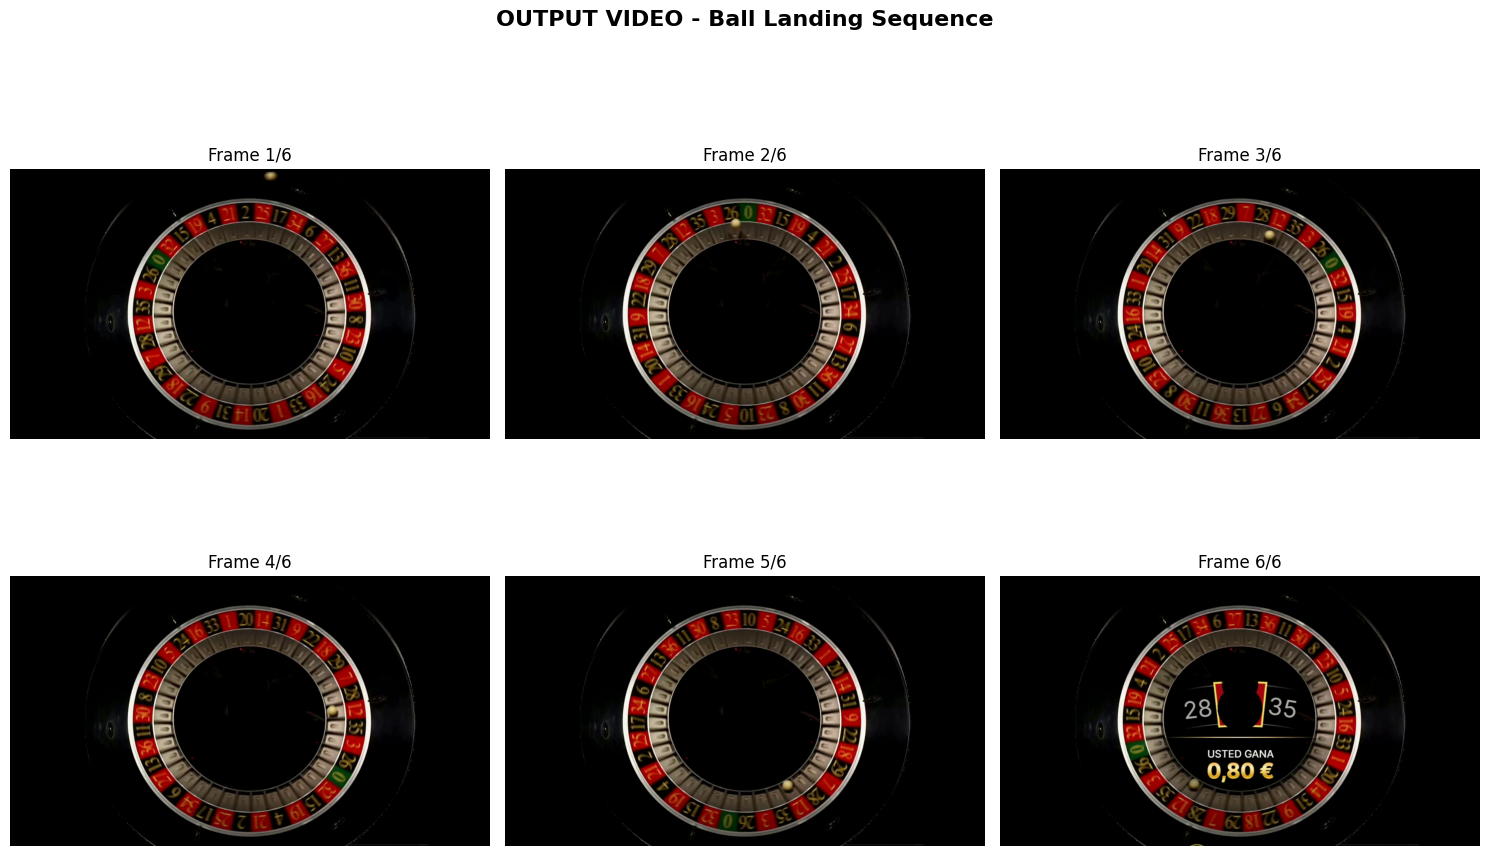

In [10]:
def extract_frames(video_path, num_frames=6):
    """Extract evenly spaced frames from video"""
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

# Extract and display frames from output video
output_frames = extract_frames(sample_output, num_frames=6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, frame in enumerate(output_frames):
    axes[i].imshow(frame)
    axes[i].set_title(f"Frame {i+1}/6", fontsize=12)
    axes[i].axis('off')
plt.suptitle("OUTPUT VIDEO - Ball Landing Sequence", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Load Labeled Dataset

In [8]:
# Load manually labeled dataset
labels_df = pd.read_csv("dataset_labels_combined.csv")

print(f"✅ Loaded {len(labels_df)} labeled videos")
print(f"\nLabel distribution:")
print(labels_df['label'].value_counts().sort_index())
print(f"\nSample entries:")
display(labels_df.head(10))

✅ Loaded 1703 labeled videos

Label distribution:
label
0     49
1     37
2     50
3     44
4     48
5     46
6     55
7     48
8     46
9     61
10    52
11    40
12    34
13    35
14    47
15    44
16    54
17    51
18    52
19    39
20    34
21    45
22    44
23    63
24    38
25    45
26    51
27    41
28    55
29    43
30    39
31    46
32    35
33    61
34    40
35    49
36    42
Name: count, dtype: int64

Sample entries:


,input_path,label,vid_id
0,../RouletteVision-Dataset/Input-Output Videos/...,12,1
1,../RouletteVision-Dataset/Input-Output Videos/...,14,10
2,../RouletteVision-Dataset/Input-Output Videos/...,35,100
3,../RouletteVision-Dataset/Input-Output Videos/...,13,101
4,../RouletteVision-Dataset/Input-Output Videos/...,16,102
5,../RouletteVision-Dataset/Input-Output Videos/...,6,103
6,../RouletteVision-Dataset/Input-Output Videos/...,29,104
7,../RouletteVision-Dataset/Input-Output Videos/...,5,105
8,../RouletteVision-Dataset/Input-Output Videos/...,29,106
9,../RouletteVision-Dataset/Input-Output Videos/...,28,107


In [9]:
# Summary statistics
print("Dataset Summary:")
print("=" * 60)
print(f"Total videos: {len(labels_df)}")
print(f"Unique labels: {labels_df['label'].nunique()}")
print(f"Samples per class: {len(labels_df) / 37:.1f} average")
print("=" * 60)

Dataset Summary:
Total videos: 1703
Unique labels: 37
Samples per class: 46.0 average
